#Decision Trees

**Objective: Learn how to apply the decision trees.**

Decision trees are widely used in the banking industry due to their high accuracy and ability to formulate a model in plain language. Since government organizations in many countries carefully monitor lending practices, banks must be able to explain why one applicant was rejected for a loan while the others were approved.

In this lab, we will develop a simple credit approval model using decision trees.

**Source: Lantz Brett, Machine Learning with R. Packt Publishing**

# I. Collecting data

The idea behind our credit model is to identify factors that are predictive of higher risk of default.

We will use a Data available in a dataset donated to the UCI Machine Learning Data Repository by Hans Hofmann of the University of Hamburg.

The dataset contains information on loans obtained from a credit agency in Germany.

The credit dataset includes 1,000 examples on loans, plus a set of numeric and nominal features indicating the characteristics of the loan and the loan applicant.

A class variable indicates whether the loan went into default.


# II. Exploring and preparing the data

## A. Exploring the data

Let’s import the data. The data is available on Canvas, named **credit.csv**.

**1. Import and read the csv data file.**

**2. Examine the structure of the data frame.**

**3.  Which features can be a possible predictor of a default loan?**

**4. How can you check and study those features? Explain.**

**5.  What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?**

## B. Data preparation

**6.Convert categorical data into numerical.**

**7. Check if your dataset is randomized.**

# III. Training a model on the data

**8. Split the data into training and testing sets.**

**9. Apply the decision tree algorithm.**

**10. Visualize the model after training**

**11. Find the best predictor features.**

# IV. Evaluating model performance

**12. Check the accuracy of the model. Check other metrics.**

**13. Is this model a good model?**

# V. Improving model performance

**14. How can you improve the performance of your decision tree model?**

**15. Apply different ways of improve the model. Discuss and explain your results.**

In [1]:
# Import and read the csv data file
import pandas as pd
credit = pd.read_csv("credit-1.csv")
credit.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [2]:
# Examine the structure of the data frame.
credit.info()
credit.describe()
credit.describe(include='object')
credit.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

(1000, 17)

# Which features can be a possible predictor of a default loan?

Checking balance, credit history, savings balance, employment duration, other credit, housing, and job could all be predictors of loan defaults. Higher balance, more skilled jobs, more credit history, more employment duration, and more savings balance could predict less likelihood of a default.

# How can you check and study those features? Explain.

You can look at a correlation matrix or use plots of those features.

In [3]:
credit.corr()

,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
months_loan_duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834
amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142
percent_of_income,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207
years_at_residence,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201
existing_loans_count,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667
dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000


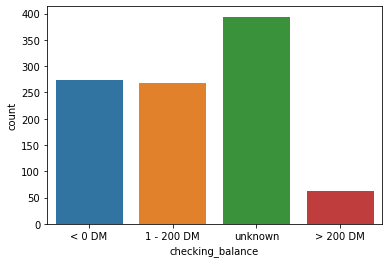

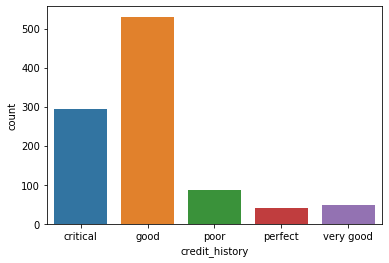

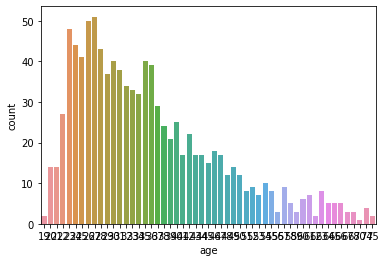

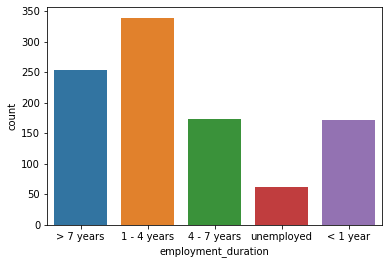

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="checking_balance", data=credit)
plt.show()

sns.countplot(x="credit_history", data=credit)
plt.show()

sns.countplot(x="age", data=credit)
plt.show()

sns.countplot(x="employment_duration", data=credit)
plt.show()

In [5]:
# What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?
credit["default"].value_counts(normalize=True) * 100

no     70.0
yes    30.0
Name: default, dtype: float64

In [6]:
# Convert categorical data into numerical.
credit_encoded = pd.get_dummies(credit, drop_first=True)

In [7]:
# Check if your dataset is randomized.
credit.head(20)
credit_encoded = credit_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

In [8]:
# Split the data into training and testing sets.
from sklearn.model_selection import train_test_split

X = credit_encoded.drop("default_yes", axis=1)
y = credit_encoded["default_yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [9]:
# Apply the decision tree algorithm
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

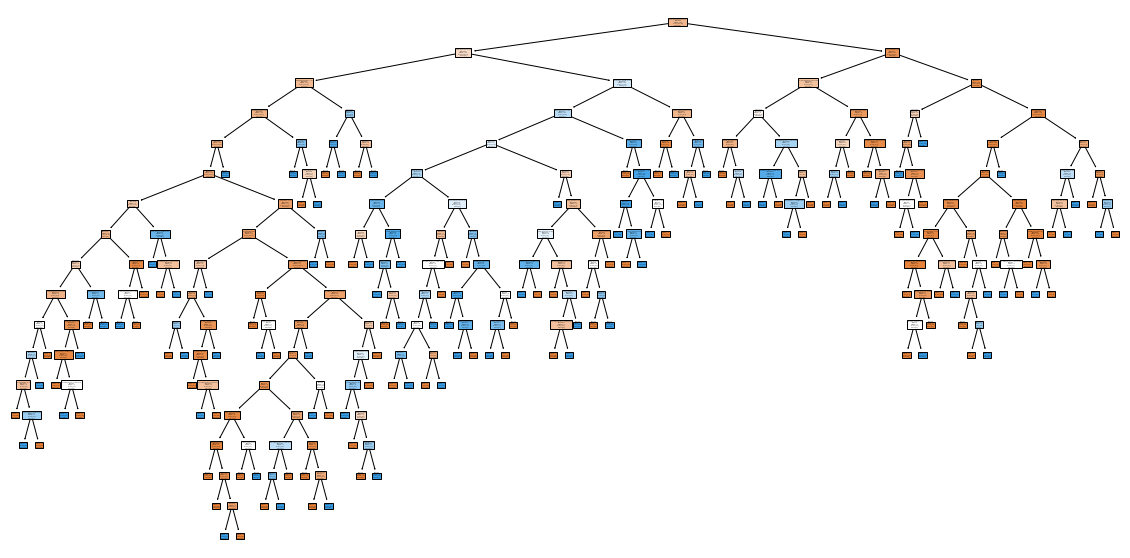

In [10]:
# Visualize the model after training
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.show()


In [11]:
# Find the best predictor features
import pandas as pd

feature_importance = pd.Series(dt.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)


age                             0.184834
amount                          0.146210
checking_balance_unknown        0.097977
months_loan_duration            0.095726
years_at_residence              0.061573
percent_of_income               0.052438
checking_balance_< 0 DM         0.045294
purpose_furniture/appliances    0.027210
other_credit_none               0.025343
phone_yes                       0.019718
dtype: float64

In [12]:
# Check the accuracy of the model. Check other metrics.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.66
[[161  49]
 [ 53  37]]
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       210
           1       0.43      0.41      0.42        90

    accuracy                           0.66       300
   macro avg       0.59      0.59      0.59       300
weighted avg       0.66      0.66      0.66       300



# Is this model a good model?

It's not terrible, but not great, you would want to be more accurate, but it is more useful than random guessing. The recall score is relatively low.

# How can you improve the performance of your decision tree model?

I will try to deal with class imbalance and try using gradient boost.

In [13]:
# Apply different ways of improve the model. Discuss and explain your results.
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced',
                               classes=classes,
                               y=y_train)

class_weights = dict(zip(classes, weights))

# Create sample weights
sample_weights = y_train.map(class_weights)

In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)


gb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train,
             classifier__sample_weight=sample_weights)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.72
[[157  53]
 [ 31  59]]
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       210
           1       0.53      0.66      0.58        90

    accuracy                           0.72       300
   macro avg       0.68      0.70      0.69       300
weighted avg       0.74      0.72      0.73       300



In [16]:
# Try random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print(accuracy_score(y_test, rf_pred))

0.7433333333333333


# Summary of findings

During the initial model training using a Decision Tree classifier, I observed that the model achieved reasonable overall accuracy of 66%, which was consistent with the class distribution of the dataset (70% non-default and 30% default). The recall for the default class was relatively low, so the model was misidentifying a significant number of high-risk borrowers.

I tried implementing class balancing techniques and using gradient boosting.

After these improvements, model performance improved slightly, but still was not great (72%). The recall increased, meaning the was better at identifying high-risk borrowers.

Random Forest worked better right from the start without doing any hyperparameter tuning or other adjustments (74%).

I think for this type of problem, accuracy is not the most important metric since the data is imbalanced. Recall and ROC would provide more meaning and show effectiveness in detecting defaulters.

Without handling imbalance, the model favored the majority class.

Additional hyperparameter tuning would increase performance metrics.